In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Code capacity

In a code capacity noise model, physical errors are sampled by flipping each bit (or depolarizing each qubit) of a code with some i.i.d. probability.  The logical error rate of a code is then the probability that a physical error is decoded incorrectly, which results in a logical error upon correction.  For a fixed noise model, this logical error rate is a joint property of (a) the code and (b) the decoder.

Our main driver for computing logical error rates in a code capacity model is the `.get_logical_error_rate_func` method of any `ClassicalCode` or `QuditCode`.  This method randomly samples and decodes a large number of physical physical errors, and returns a function that estimates the logical error rate for any given physical error rate.  Below, we use this method to produce a plot of physical vs. logical error rates for a few codes.

### imports, simulation, and plotting code

In [2]:
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
from sympy.abc import x, y

from qldpc import codes

from common import get_label

%matplotlib inline

In [3]:
def make_code_capacity_figure(
    codes_to_plot: Sequence[codes.ClassicalCode | codes.QuditCode],
    error_rates: Sequence[float] = list(np.logspace(-2, -0.1, 100)),
    num_samples: int = 10**4,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (5, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot physical vs. logical error rates for the given codes in a code capacity model.

    Args:
        codes_to_plot: The codes whose error rates we want to plot.
        error_rates: The i.i.d. probabilities of physical errors on each bit/qubit.
        num_samples: The number of physical errors to sample in a simulation.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The distance (or its estimate) is used to label each code in the legend.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    figure, axis = plt.subplots(figsize=figsize)

    for code in codes_to_plot:
        # this is the slow part where the simulations happen
        get_logical_error_rate = code.get_logical_error_rate_func(
            num_samples, max(error_rates), **decoding_kwargs
        )

        # this part is fast
        logical_rates, stderrs = get_logical_error_rate(error_rates)

        # add these results to the figure
        label = get_label(code, distance_trials)
        line, *_ = axis.plot(error_rates, logical_rates, label=label)
        axis.fill_between(
            error_rates,
            logical_rates - stderrs,
            logical_rates + stderrs,
            color=line.get_color(),
            alpha=0.2,
        )

    # add a reference line for p_log = p_phys, and clean up the figure
    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.loglog()
    axis.set_xlim(right=1)
    axis.set_ylim(bottom=max(min(error_rates) ** 2, axis.get_ylim()[0]), top=1)
    axis.set_xlabel(r"physical error rate")
    axis.set_ylabel(r"logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both")
    figure.tight_layout()

    return figure, axis

### Repetition and surface codes

These codes can be decodes with minimum-weight perfect matching (MWPM).

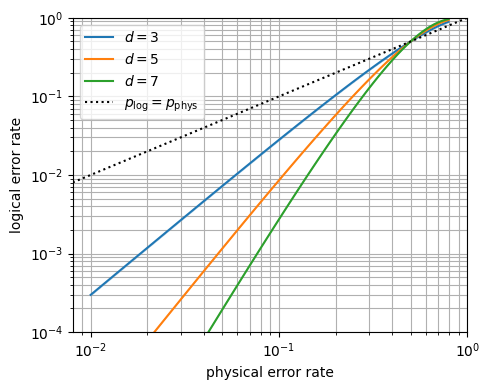

In [4]:
rep_codes = [codes.RepetitionCode(dist) for dist in [3, 5, 7]]
make_code_capacity_figure(rep_codes, with_MWPM=True)
plt.show()

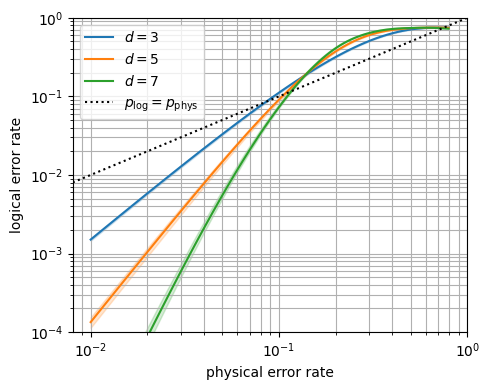

In [5]:
surface_codes = [codes.SurfaceCode(dist) for dist in [3, 5, 7]]
make_code_capacity_figure(surface_codes, with_MWPM=True)
plt.show()

### Bivariate bicycle codes

As introduced in [arXiv:2308.07915](https://arxiv.org/abs/2308.07915), these codes can be decoded with (for example) [BD-LSD](https://arxiv.org/abs/2406.18655).

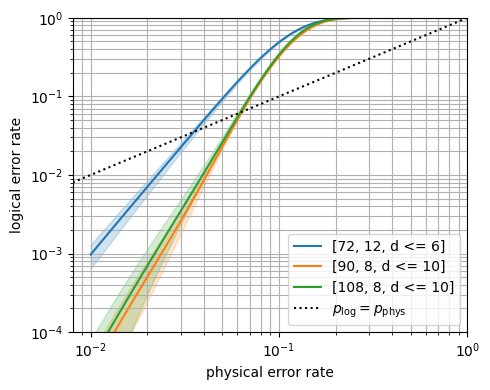

In [6]:
bb_codes = [
    codes.BBCode(
        {x: 6, y: 6},
        x**3 + y + y**2,
        y**3 + x + x**2,
    ),
    codes.BBCode(
        {x: 15, y: 3},
        x**9 + y + y**2,
        1 + x**2 + x**7,
    ),
    codes.BBCode(
        {x: 9, y: 6},
        x**3 + y + y**2,
        y**3 + x + x**2,
    ),
]
make_code_capacity_figure(bb_codes, with_BP_LSD=True)
plt.show()